/var/folders/24/f9mpl0gx1rs5tb1xb_z_cqmw0000gn/T/ipykernel_82337/229230215.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


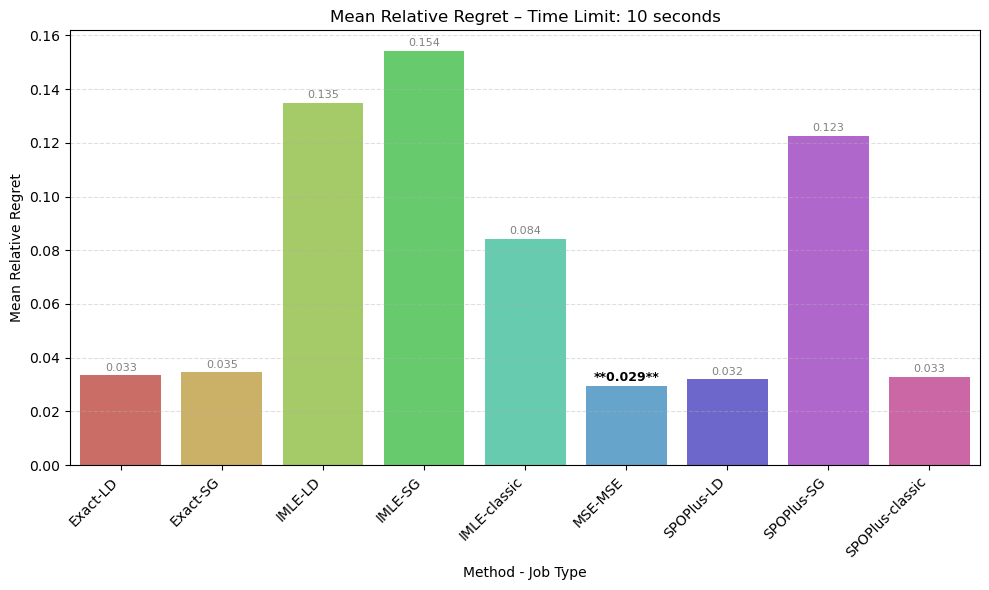

/var/folders/24/f9mpl0gx1rs5tb1xb_z_cqmw0000gn/T/ipykernel_82337/229230215.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


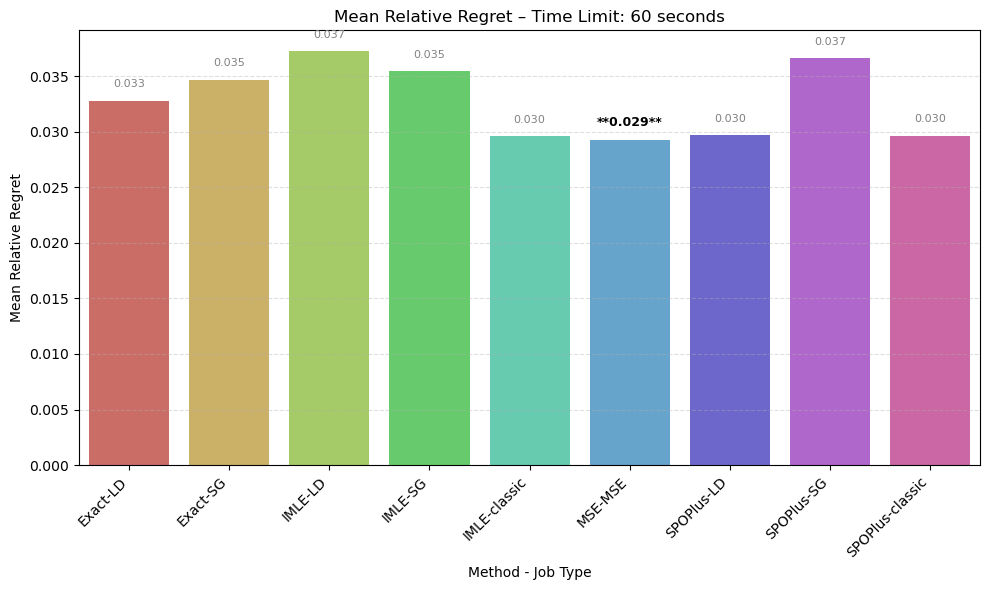

/var/folders/24/f9mpl0gx1rs5tb1xb_z_cqmw0000gn/T/ipykernel_82337/229230215.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


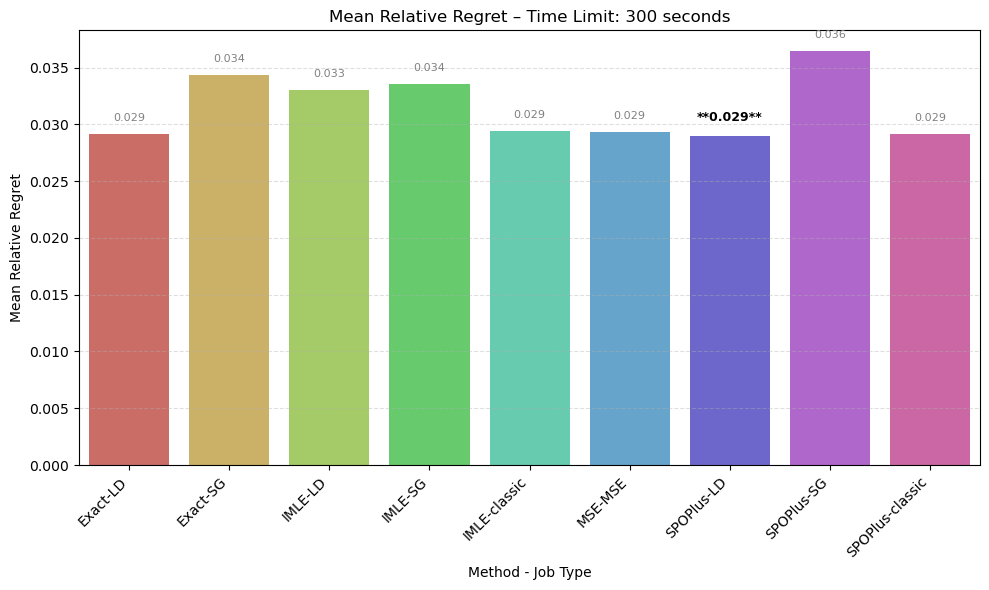

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
df = pd.read_csv("portfolio/results_temps_deg4.csv")

# Créer colonne method-jobtype
df["method_jobtype"] = df["method"] + "-" + df["jobtype"].astype(str)

# Grouper
grouped = df.groupby(["time limit", "method_jobtype"])["mean_relat_test"].mean().reset_index()

# Liste des time limits
time_limits = sorted(grouped["time limit"].unique())

# Palette
palette = sns.color_palette("hls", len(grouped["method_jobtype"].unique()))

for t in time_limits:
    subset = grouped[grouped["time limit"] == t].copy()
    
    # Identifier la meilleure (plus bas regret)
    best_idx = subset["mean_relat_test"].idxmin()
    best_row = subset.loc[best_idx]
    
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=subset,
        x="method_jobtype",
        y="mean_relat_test",
        palette=palette
    )
    
    # Titre
    plt.title(f"Mean Relative Regret – Time Limit: {int(t)} seconds")
    plt.xlabel("Method - Job Type")
    plt.ylabel("Mean Relative Regret")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    
    # Annoter la meilleure barre
    for i, bar in enumerate(ax.patches):
        val = subset.iloc[i]["mean_relat_test"]
        label = f"{val:.3f}"
        if i == list(subset.index).index(best_idx):
            # En gras pour la meilleure
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f"**{label}**",
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold',
                color='black'
            )
        else:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                label,
                ha='center',
                va='bottom',
                fontsize=8,
                color='gray'
            )
    
    plt.tight_layout()
    plt.show()

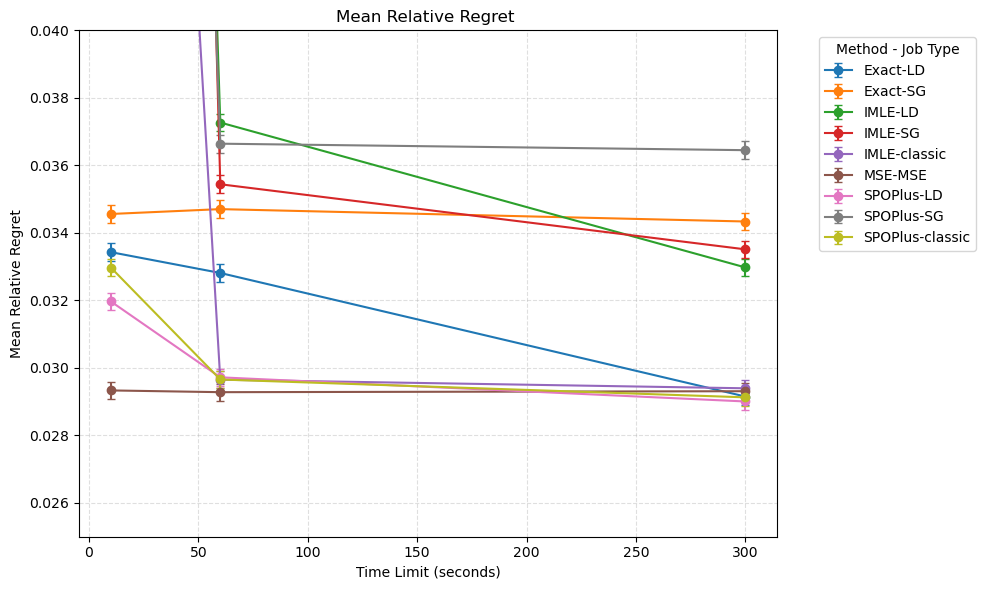

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Charger les données
df = pd.read_csv("portfolio/results_temps_deg8.csv")
df_muloss = pd.read_csv("portfolio/results_temps_deg8_muloss_0.csv")

# Créer identifiant méthode-type
df["method_jobtype"] = df["method"] + "-" + df["jobtype"].astype(str)

# Calcul de l'intervalle de confiance 95 %
df["ci95"] = 1.96 * df["std_relat_test"] / np.sqrt(10000)

# Moyenne et CI groupées
grouped = df.groupby(["method_jobtype", "time limit"]).agg(
    mean=("mean_relat_test", "mean"),
    ci95=("ci95", "mean")
).reset_index()

# Palette
palette = sns.color_palette("tab10", n_colors=grouped["method_jobtype"].nunique())

# Tracer les courbes avec barres d'erreur
plt.figure(figsize=(10, 6))
for i, (name, group) in enumerate(grouped.groupby("method_jobtype")):
    group = group.sort_values("time limit")
    plt.errorbar(
        group["time limit"],
        group["mean"],
        yerr=group["ci95"],
        label=name,
        marker='o',
        capsize=3,
        linestyle='-',
        color=palette[i]
    )

plt.title("Mean Relative Regret ")
plt.xlabel("Time Limit (seconds)")
plt.ylabel("Mean Relative Regret")
plt.ylim(0.025, 0.04)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Method - Job Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def filter_dataframe(csv_path, time_limit, method, jobtype, step_mu, n_iter_mu, suffix=""):
    """
    Filtre un CSV selon les paramètres donnés et retourne un DataFrame avec CI95.
    Un suffixe peut être ajouté à l'identifiant méthode-jobtype.
    """
    df = pd.read_csv(csv_path)

    filtered = df[
        (df["time limit"] == time_limit) &
        (df["method"] == method) &
        (df["jobtype"] == jobtype) &
        (df["step_mu"] == step_mu) &
        (df["num_iter_mu"] == n_iter_mu)
    ].copy()

    if filtered.empty:
        print(f"[WARN] Aucune ligne trouvée pour : {method}-{jobtype}{suffix} @ {time_limit}s")
        return filtered

    # Ajouter identifiant unique avec suffixe
    filtered["method_jobtype"] = f"{method}-{jobtype}{suffix}"
    
    # Ajouter CI 95 %
    filtered["ci95"] = 1.96 * filtered["std_relat_test"] / np.sqrt(10000)

    return filtered


def merge_dataframes(df_list):
    """
    Fusionne plusieurs DataFrames filtrés.
    """
    return pd.concat(df_list, ignore_index=True)


def plot_mean_regret_with_ci(df, title="Mean Relative Regret with 95% CI"):
    """
    Trace le graphique avec moyenne + intervalle de confiance.
    """
    grouped = df.groupby(["method_jobtype", "time limit"]).agg(
        mean=("mean_relat_test", "mean"),
        ci95=("ci95", "mean")
    ).reset_index()

    unique_labels = grouped["method_jobtype"].unique()
    colors = plt.get_cmap("tab10")(np.linspace(0, 1, len(unique_labels)))

    plt.figure(figsize=(10, 6))
    for i, label in enumerate(unique_labels):
        subset = grouped[grouped["method_jobtype"] == label].sort_values("time limit")
        plt.errorbar(
            subset["time limit"],
            subset["mean"],
            yerr=subset["ci95"],
            label=label,
            marker='o',
            linestyle='-',
            capsize=3,
            color=colors[i]
        )

    plt.title(title)
    plt.xlabel("Time Limit (seconds)")
    plt.ylabel("Mean Relative Regret")
    plt.ylim(0.08, 0.25)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(title="Method - Job Type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

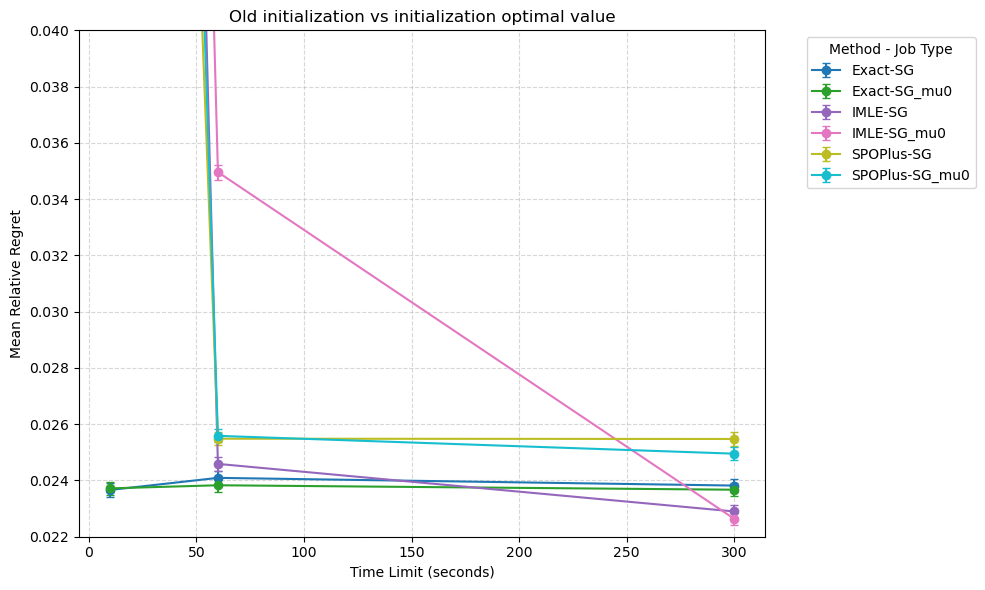

In [ ]:
# Exemple d'usage


csv = "portfolio/results_temps_deg8.csv"
csv_loss = "portfolio/results_temps_deg_8_muloss_0.csv"
csv_mu0 = "portfolio/results_temps_deg_8mu0.csv"

cla_IMLE_10_df = filter_dataframe(csv, 10, "IMLE", "classic", 5, 15)
cla_IMLE_60_df = filter_dataframe(csv, 60, "IMLE", "classic", 5, 15)
cla_IMLE_300_df = filter_dataframe(csv, 300, "IMLE", "classic", 5, 15)
cla_SPOPlus_10_df = filter_dataframe(csv, 10, "SPOPlus", "classic", 5, 15)
cla_SPOPlus_60_df = filter_dataframe(csv, 60, "SPOPlus", "classic", 5, 15)
cla_SPOPlus_300_df = filter_dataframe(csv, 300, "SPOPlus", "classic", 5, 15)
MSE_MSE_10_df = filter_dataframe(csv, 10, "MSE", "MSE", 5, 15)
MSE_MSE_60_df = filter_dataframe(csv, 60, "MSE", "MSE", 5, 15)
MSE_MSE_300_df = filter_dataframe(csv, 300, "MSE", "MSE", 5, 15)
LD_Exact_10_df = filter_dataframe(csv, 10, "Exact", "LD", 5, 15)
LD_Exact_60_df = filter_dataframe(csv, 60, "Exact", "LD", 5, 15)
LD_Exact_300_df = filter_dataframe(csv, 300, "Exact", "LD", 5, 15)
SG_Exact_10_df = filter_dataframe(csv, 10, "Exact", "SG", 20, 10)
SG_Exact_60_df = filter_dataframe(csv, 60, "Exact", "SG", 20, 10)
SG_Exact_300_df = filter_dataframe(csv, 300, "Exact", "SG", 5, 10)

LD_Exact_10_loss_df = filter_dataframe(csv_loss, 10, "Exact", "LD", 5, 15, suffix="_loss")
LD_Exact_60_loss_df = filter_dataframe(csv_loss, 60, "Exact", "LD", 5, 15, suffix="_loss")
LD_Exact_300_loss_df = filter_dataframe(csv_loss, 300, "Exact", "LD", 5, 15, suffix="_loss")
SG_Exact_10_loss_df = filter_dataframe(csv_loss, 10, "Exact", "SG", 20, 10, suffix="_loss")
SG_Exact_60_loss_df = filter_dataframe(csv_loss, 60, "Exact", "SG", 20, 10, suffix="_loss")
SG_Exact_300_loss_df = filter_dataframe(csv_loss, 300, "Exact", "SG", 20, 10, suffix="_loss")

SG_SPOPlus_10_df = filter_dataframe(csv, 10, "SPOPlus", "SG", 10, 10)
SG_SPOPlus_60_df = filter_dataframe(csv, 60, "SPOPlus", "SG", 10, 10)
SG_SPOPlus_300_df = filter_dataframe(csv, 300, "SPOPlus", "SG", 5, 10)
SG_IMLE_10_df = filter_dataframe(csv, 10, "IMLE", "SG", 10, 10)
SG_IMLE_60_df = filter_dataframe(csv, 60, "IMLE", "SG", 10, 10)
SG_IMLE_300_df = filter_dataframe(csv, 300, "IMLE", "SG", 5, 10)

SG_SPOPlus_10_mu0_df = filter_dataframe(csv_mu0, 10, "SPOPlus", "SG", 20, 10, suffix="_mu0")
SG_SPOPlus_60_mu0_df = filter_dataframe(csv_mu0, 60, "SPOPlus", "SG", 20, 10, suffix="_mu0")
SG_SPOPlus_300_mu0_df = filter_dataframe(csv_mu0, 300, "SPOPlus", "SG", 20, 10, suffix="_mu0")
SG_IMLE_10_mu0_df = filter_dataframe(csv_mu0, 10, "IMLE", "SG", 20, 10, suffix="_mu0")
SG_IMLE_60_mu0_df = filter_dataframe(csv_mu0, 60, "IMLE", "SG", 20, 10, suffix="_mu0")
SG_IMLE_300_mu0_df = filter_dataframe(csv_mu0, 300, "IMLE", "SG", 20, 10, suffix="_mu0")
SG_Exact_10_mu0_df = filter_dataframe(csv_mu0, 10, "Exact", "SG", 20, 10, suffix="_mu0")
SG_Exact_60_mu0_df = filter_dataframe(csv_mu0, 60, "Exact", "SG", 20, 10, suffix="_mu0")
SG_Exact_300_mu0_df = filter_dataframe(csv_mu0, 300, "Exact", "SG", 20, 10, suffix="_mu0")


# Fusionner
merged_df = merge_dataframes([
    # cla_IMLE_10_df, cla_IMLE_60_df, cla_IMLE_300_df,
    # cla_SPOPlus_10_df, cla_SPOPlus_60_df, cla_SPOPlus_300_df,
    # MSE_MSE_10_df, MSE_MSE_60_df, MSE_MSE_300_df,
    #LD_Exact_10_df, LD_Exact_60_df, LD_Exact_300_df,
    SG_Exact_10_df, SG_Exact_60_df, SG_Exact_300_df,
    # LD_Exact_10_loss_df, LD_Exact_60_loss_df, LD_Exact_300_loss_df,
    # SG_Exact_10_loss_df, SG_Exact_60_loss_df, SG_Exact_300_loss_df,
    SG_SPOPlus_10_df, SG_SPOPlus_60_df, SG_SPOPlus_300_df,
    SG_IMLE_10_df, SG_IMLE_60_df, SG_IMLE_300_df,
    SG_SPOPlus_10_mu0_df, SG_SPOPlus_60_mu0_df, SG_SPOPlus_300_mu0_df,
    SG_IMLE_10_mu0_df, SG_IMLE_60_mu0_df, SG_IMLE_300_mu0_df,
    SG_Exact_10_mu0_df, SG_Exact_60_mu0_df, SG_Exact_300_mu0_df,
])

#plot
plot_mean_regret_with_ci(merged_df, title="Old initialization vs initialization optimal value")

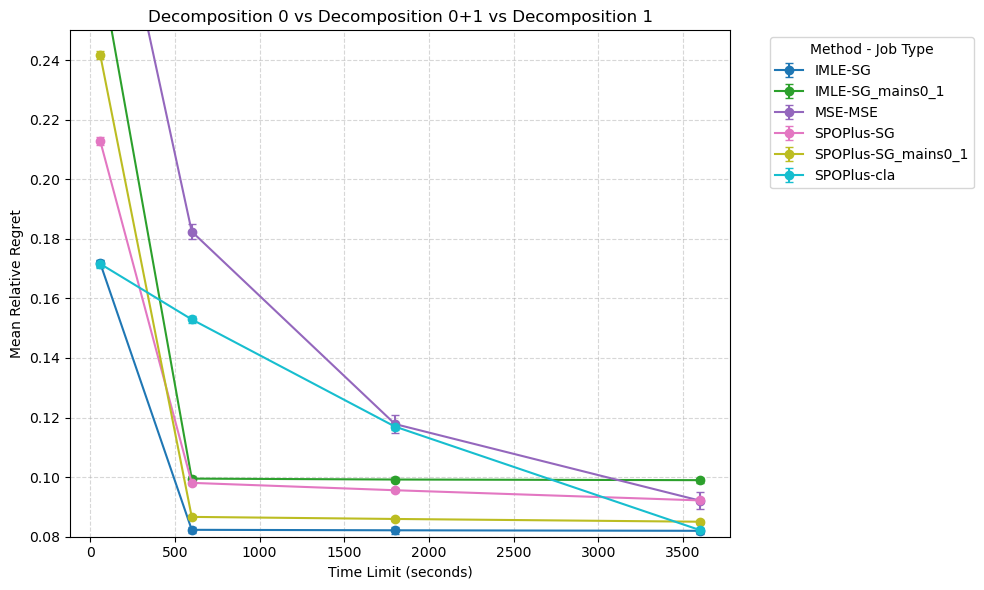

In [85]:

csv = "knapsack/results_deg8.csv"
csv_loss = "knapsack/results_deg8_muloss_0.csv"
csv_mains1 = "knapsack/results_deg8_mains1.csv"
csv_mains0_1 = "knapsack/results_deg8_mains0_1.csv"

cla_IMLE_60_df    = filter_dataframe(csv, 60, "IMLE", "cla", 1, 10)
cla_IMLE_600_df   = filter_dataframe(csv, 600, "IMLE", "cla", 1, 10)
cla_IMLE_1800_df  = filter_dataframe(csv, 1800, "IMLE", "cla", 1, 10)
cla_IMLE_3600_df  = filter_dataframe(csv, 3600, "IMLE", "cla", 1, 10)

cla_SPOPlus_60_df    = filter_dataframe(csv, 60, "SPOPlus", "cla", 1, 10)
cla_SPOPlus_600_df   = filter_dataframe(csv, 600, "SPOPlus", "cla", 1, 10)
cla_SPOPlus_1800_df  = filter_dataframe(csv, 1800, "SPOPlus", "cla", 1, 10)
cla_SPOPlus_3600_df  = filter_dataframe(csv, 3600, "SPOPlus", "cla", 1, 10)

MSE_MSE_60_df    = filter_dataframe(csv, 60, "MSE", "MSE", 1, 10)
MSE_MSE_600_df   = filter_dataframe(csv, 600, "MSE", "MSE", 1, 10)
MSE_MSE_1800_df  = filter_dataframe(csv, 1800, "MSE", "MSE", 1, 10)
MSE_MSE_3600_df  = filter_dataframe(csv, 3600, "MSE", "MSE", 1, 10)

SG_IMLE_60_df    = filter_dataframe(csv, 60, "IMLE", "SG", 20, 20)
SG_SPOPlus_60_df    = filter_dataframe(csv, 60, "SPOPlus", "SG", 20, 10)
SG_IMLE_600_df   = filter_dataframe(csv, 600, "IMLE", "SG", 5, 10)
SG_SPOPlus_600_df   = filter_dataframe(csv, 600, "SPOPlus", "SG", 10, 10)
SG_IMLE_1800_df  = filter_dataframe(csv, 1800, "IMLE", "SG", 5, 10)
SG_SPOPlus_1800_df  = filter_dataframe(csv, 1800, "SPOPlus", "SG", 10, 10)
SG_IMLE_3600_df  = filter_dataframe(csv, 3600, "IMLE", "SG", 5, 10)
SG_SPOPlus_3600_df  = filter_dataframe(csv, 3600, "SPOPlus", "SG", 10, 10)

SG_IMLE_60_loss_df    = filter_dataframe(csv_loss, 60, "IMLE", "SG", 20, 20, suffix="_loss")
SG_IMLE_600_loss_df   = filter_dataframe(csv_loss, 600, "IMLE", "SG", 20, 20, suffix="_loss")
SG_IMLE_1800_loss_df  = filter_dataframe(csv_loss, 1800, "IMLE", "SG", 20, 20, suffix="_loss")
SG_IMLE_3600_loss_df  = filter_dataframe(csv_loss, 3600, "IMLE", "SG", 20, 20, suffix="_loss")

SG_IMLE_60_mains0_1 = filter_dataframe(csv_mains0_1, 60, "IMLE", "SG", 20, 10, suffix="_mains0_1")
SG_IMLE_600_mains0_1 = filter_dataframe(csv_mains0_1, 600, "IMLE", "SG", 5, 10, suffix="_mains0_1")
SG_IMLE_1800_mains0_1 = filter_dataframe(csv_mains0_1, 1800, "IMLE", "SG", 5, 10, suffix="_mains0_1")
SG_IMLE_3600_mains0_1 = filter_dataframe(csv_mains0_1, 3600, "IMLE", "SG", 5, 10, suffix="_mains0_1")
SG_SPOPlus_60_mains0_1 = filter_dataframe(csv_mains0_1, 60, "SPOPlus", "SG", 10, 10, suffix="_mains0_1")
SG_SPOPlus_600_mains0_1 = filter_dataframe(csv_mains0_1, 600, "SPOPlus", "SG", 5, 10, suffix="_mains0_1")
SG_SPOPlus_1800_mains0_1 = filter_dataframe(csv_mains0_1, 1800, "SPOPlus", "SG", 5, 10, suffix="_mains0_1")
SG_SPOPlus_3600_mains0_1 = filter_dataframe(csv_mains0_1, 3600, "SPOPlus", "SG", 5, 10, suffix="_mains0_1")

SG_IMLE_60_mains1_df = filter_dataframe(csv_mains1, 60, "IMLE", "SG", 20, 10, suffix="_mains1")
SG_IMLE_600_mains1_df = filter_dataframe(csv_mains1, 600, "IMLE", "SG", 20, 20, suffix="_mains1")
SG_IMLE_1800_mains1_df = filter_dataframe(csv_mains1, 1800, "IMLE", "SG", 20, 20, suffix="_mains1")
SG_IMLE_3600_mains1_df = filter_dataframe(csv_mains1, 3600, "IMLE", "SG", 20, 20, suffix="_mains1")
SG_SPOPlus_60_mains1_df = filter_dataframe(csv_mains1, 60, "SPOPlus", "SG", 10, 10, suffix="_mains1")
SG_SPOPlus_600_mains1_df = filter_dataframe(csv_mains1, 600, "SPOPlus", "SG", 10, 20, suffix="_mains1")
SG_SPOPlus_1800_mains1_df = filter_dataframe(csv_mains1, 1800, "SPOPlus", "SG", 10, 20, suffix="_mains1")
SG_SPOPlus_3600_mains1_df = filter_dataframe(csv_mains1, 3600, "SPOPlus", "SG", 10, 20, suffix="_mains1")


# fusionner
merged_knapsack_df = merge_dataframes([
    # cla_IMLE_60_df, cla_IMLE_600_df, cla_IMLE_1800_df, cla_IMLE_3600_df,
    cla_SPOPlus_60_df, cla_SPOPlus_600_df, cla_SPOPlus_1800_df, cla_SPOPlus_3600_df,
    MSE_MSE_60_df, MSE_MSE_600_df, MSE_MSE_1800_df, MSE_MSE_3600_df,
    SG_IMLE_60_df, SG_IMLE_600_df, SG_IMLE_1800_df, SG_IMLE_3600_df,
    SG_SPOPlus_60_df, SG_SPOPlus_600_df, SG_SPOPlus_1800_df, SG_SPOPlus_3600_df,
    # SG_IMLE_60_loss_df, SG_IMLE_600_loss_df, SG_IMLE_1800_loss_df, SG_IMLE_3600_loss_df,
    SG_IMLE_60_mains0_1, SG_IMLE_600_mains0_1, SG_IMLE_1800_mains0_1, SG_IMLE_3600_mains0_1,
    SG_SPOPlus_60_mains0_1, SG_SPOPlus_600_mains0_1, SG_SPOPlus_1800_mains0_1, SG_SPOPlus_3600_mains0_1,
    # SG_IMLE_60_mains1_df, SG_IMLE_600_mains1_df, SG_IMLE_1800_mains1_df, SG_IMLE_3600_mains1_df,
    # SG_SPOPlus_60_mains1_df, SG_SPOPlus_600_mains1_df, SG_SPOPlus_1800_mains1_df, SG_SPOPlus_3600_mains1_df,

])

# Tracer le graphique pour knapsack
plot_mean_regret_with_ci(merged_knapsack_df, title="Decomposition 0 vs Decomposition 0+1 vs Decomposition 1")




